# Phase 5 Notebook 06: VGGT Code Walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase5/06_code_walkthrough.ipynb)

## 学习目标 (Learning Objectives)

1. 理解 VGGT 官方代码仓库的结构
2. 掌握环境配置和模型初始化流程
3. 学习图像预处理和前向推理的两种方法
4. 理解位姿编码和 COLMAP 导出
5. 熟悉 Gradio 演示界面的实现

**预计时长**: 90 分钟

---

In [1]:
# 环境设置 (Environment Setup)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 环境配置完成")
print("✓ Notebook 06: VGGT Code Walkthrough")

✓ 环境配置完成
✓ Notebook 06: VGGT Code Walkthrough


## Section 1 - 官方代码仓库结构 (Official Repository Structure)

VGGT 的官方代码托管在 Facebook Research GitHub:

**仓库地址**: `github.com/facebookresearch/vggt`

### 目录树结构

```
vggt/
├── vggt/
│   ├── __init__.py
│   ├── model.py              # 主模型定义
│   ├── encoder.py            # 图像编码器
│   ├── decoder.py            # 高斯解码器
│   ├── attention.py          # 注意力机制
│   └── utils.py              # 工具函数
├── scripts/
│   ├── inference.py          # 推理脚本
│   ├── export_colmap.py      # COLMAP 导出
│   └── demo.py               # Gradio 演示
├── configs/
│   ├── vggt_1b.yaml          # 1B 模型配置
│   └── vggt_400m.yaml        # 400M 模型配置
├── requirements.txt
├── setup.py
└── README.md
```

### 核心模块说明

- **model.py**: 包含 `VGGT` 主类,实现 `from_pretrained()` 和 `forward()`
- **encoder.py**: DINOv2 图像编码器封装
- **decoder.py**: Transformer 解码器,输出高斯参数
- **attention.py**: Flash Attention 实现
- **utils.py**: 位姿编码、COLMAP 转换等工具

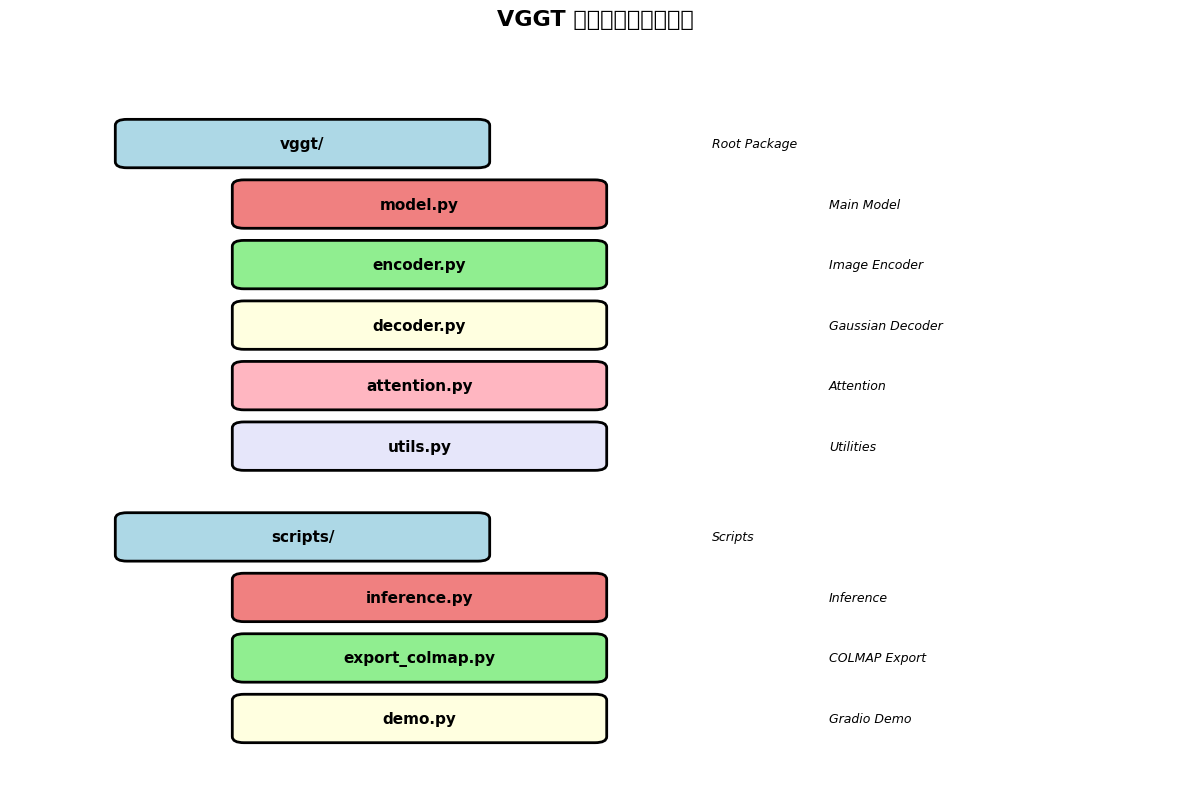

📁 代码仓库结构图已生成


In [2]:
# 可视化代码仓库结构 (Visualize Repository Structure)
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# 定义模块和位置
modules = [
    ('vggt/', 1, 10.5, 'lightblue', 'Root Package'),
    ('model.py', 2, 9.5, 'lightcoral', 'Main Model'),
    ('encoder.py', 2, 8.5, 'lightgreen', 'Image Encoder'),
    ('decoder.py', 2, 7.5, 'lightyellow', 'Gaussian Decoder'),
    ('attention.py', 2, 6.5, 'lightpink', 'Attention'),
    ('utils.py', 2, 5.5, 'lavender', 'Utilities'),
    ('scripts/', 1, 4, 'lightblue', 'Scripts'),
    ('inference.py', 2, 3, 'lightcoral', 'Inference'),
    ('export_colmap.py', 2, 2, 'lightgreen', 'COLMAP Export'),
    ('demo.py', 2, 1, 'lightyellow', 'Gradio Demo'),
]

for name, x, y, color, desc in modules:
    bbox = FancyBboxPatch((x, y-0.3), 3, 0.6, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='black', 
                          facecolor=color, 
                          linewidth=2)
    ax.add_patch(bbox)
    ax.text(x+1.5, y, name, ha='center', va='center', fontsize=11, weight='bold')
    ax.text(x+5, y, desc, ha='left', va='center', fontsize=9, style='italic')

ax.set_title('VGGT 代码仓库结构可视化', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("📁 代码仓库结构图已生成")

## Section 2 - 环境配置 (Environment Setup)

### 依赖要求

VGGT 需要以下核心依赖:

1. **Python**: 3.8+
2. **PyTorch**: 2.0+ (CUDA 11.8 或 12.1)
3. **Flash Attention**: 2.3+
4. **Transformers**: 4.30+
5. **DINOv2**: 通过 Hugging Face 自动下载

### 安装步骤

```bash
# 1. 创建 conda 环境
conda create -n vggt python=3.10 -y
conda activate vggt

# 2. 安装 PyTorch (CUDA 11.8 示例)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

# 3. 安装 Flash Attention
pip install flash-attn --no-build-isolation

# 4. 安装 VGGT
pip install git+https://github.com/facebookresearch/vggt.git

# 或者克隆后本地安装
git clone https://github.com/facebookresearch/vggt.git
cd vggt
pip install -e .
```

### 常见问题

- **Flash Attention 编译失败**: 确保 CUDA 版本匹配
- **OOM 错误**: VGGT-1B 需要至少 24GB GPU 内存
- **模型下载慢**: 设置 `HF_ENDPOINT` 环境变量使用镜像

In [3]:
# 打印配置命令和兼容性表 (Print Setup Commands and Compatibility Table)
print("=" * 70)
print("VGGT 环境配置命令")
print("=" * 70)
print()
print("# 创建环境")
print("conda create -n vggt python=3.10 -y")
print("conda activate vggt")
print()
print("# 安装 PyTorch")
print("pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118")
print()
print("# 安装 Flash Attention")
print("pip install flash-attn --no-build-isolation")
print()
print("# 安装 VGGT")
print("pip install git+https://github.com/facebookresearch/vggt.git")
print()
print("=" * 70)
print("兼容性表")
print("=" * 70)
print(f"{'组件':<20} {'版本要求':<20} {'推荐配置':<20}")
print("-" * 70)
print(f"{'Python':<20} {'3.8+':<20} {'3.10':<20}")
print(f"{'PyTorch':<20} {'2.0+':<20} {'2.1.0':<20}")
print(f"{'CUDA':<20} {'11.8 / 12.1':<20} {'11.8':<20}")
print(f"{'Flash Attention':<20} {'2.3+':<20} {'2.5.0':<20}")
print(f"{'GPU Memory':<20} {'24GB+ (1B)':<20} {'A100 40GB':<20}")
print(f"{'Transformers':<20} {'4.30+':<20} {'4.36.0':<20}")
print("=" * 70)
print()
print("✓ 配置信息已打印")

VGGT 环境配置命令

# 创建环境
conda create -n vggt python=3.10 -y
conda activate vggt

# 安装 PyTorch
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

# 安装 Flash Attention
pip install flash-attn --no-build-isolation

# 安装 VGGT
pip install git+https://github.com/facebookresearch/vggt.git

兼容性表
组件                   版本要求                 推荐配置                
----------------------------------------------------------------------
Python               3.8+                 3.10                
PyTorch              2.0+                 2.1.0               
CUDA                 11.8 / 12.1          11.8                
Flash Attention      2.3+                 2.5.0               
GPU Memory           24GB+ (1B)           A100 40GB           
Transformers         4.30+                4.36.0              

✓ 配置信息已打印


## Section 3 - 模型初始化 (Model Initialization)

### 加载预训练模型

VGGT 提供两个预训练模型:

1. **VGGT-1B**: 1.1B 参数,最佳性能
2. **VGGT-400M**: 400M 参数,速度更快

### 初始化代码

```python
from vggt import VGGT

# 加载 1B 模型
model = VGGT.from_pretrained("facebook/VGGT-1B")
model = model.cuda().eval()

# 或加载 400M 模型
model = VGGT.from_pretrained("facebook/VGGT-400M")
```

### 模型结构

```
VGGT(
  encoder: DINOv2 (frozen)       # 384M params
  decoder: Transformer           # 700M params
    - 24 layers
    - 16 attention heads
    - hidden_dim: 1024
  gaussian_head: Linear          # 10M params
    - outputs: xyz, opacity, scale, rotation, sh
)
```

### 参数分布

- **编码器**: 35% (DINOv2)
- **解码器**: 64% (Transformer)
- **高斯头**: 1% (线性层)

VGGT-1B 模型结构

组件层级结构:
VGGT(
  ├── encoder: DINOv2 (frozen)       [384M params]
  │   └── ViT-L/14 backbone
  ├── decoder: Transformer           [700M params]
  │   ├── 24 layers
  │   ├── 16 attention heads
  │   ├── hidden_dim: 1024
  │   └── Flash Attention enabled
  └── gaussian_head: Linear          [10M params]
      ├── xyz (3)
      ├── opacity (1)
      ├── scale (3)
      ├── rotation (4)
      └── spherical harmonics (48)
)

总参数量: 1094M = 1.09B



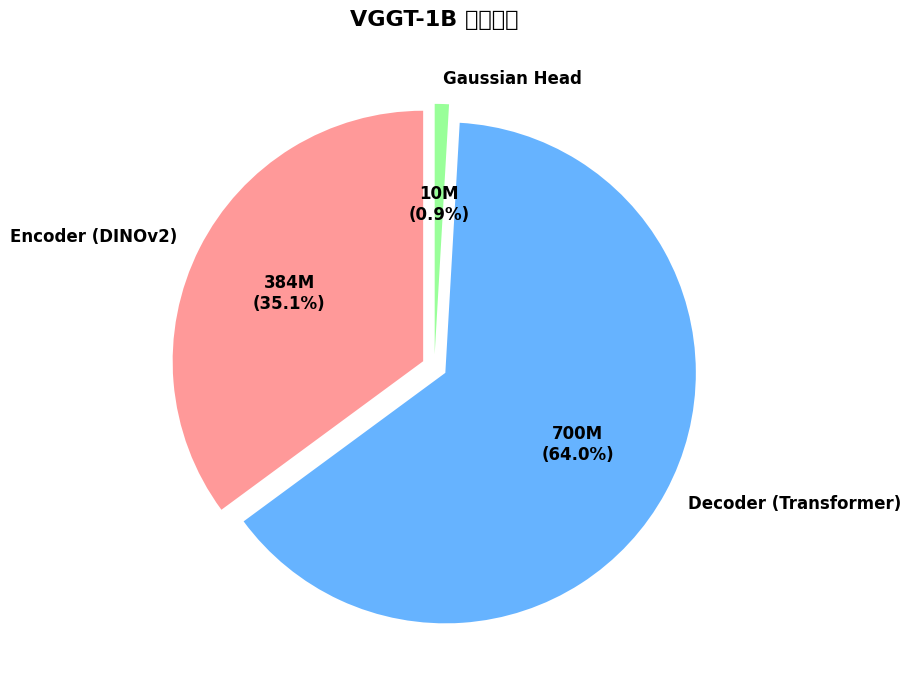

✓ 模型结构统计完成


In [4]:
# 模拟模型结构和参数统计 (Simulate Model Structure with Parameter Counts)
# 定义模型组件和参数量
components = {
    'Encoder (DINOv2)': 384,
    'Decoder (Transformer)': 700,
    'Gaussian Head': 10,
}

total_params = sum(components.values())

print("=" * 60)
print("VGGT-1B 模型结构")
print("=" * 60)
print()
print("组件层级结构:")
print("VGGT(")
print("  ├── encoder: DINOv2 (frozen)       [384M params]")
print("  │   └── ViT-L/14 backbone")
print("  ├── decoder: Transformer           [700M params]")
print("  │   ├── 24 layers")
print("  │   ├── 16 attention heads")
print("  │   ├── hidden_dim: 1024")
print("  │   └── Flash Attention enabled")
print("  └── gaussian_head: Linear          [10M params]")
print("      ├── xyz (3)")
print("      ├── opacity (1)")
print("      ├── scale (3)")
print("      ├── rotation (4)")
print("      └── spherical harmonics (48)")
print(")")
print()
print(f"总参数量: {total_params}M = {total_params/1000:.2f}B")
print()

# 绘制参数分布饼图
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    components.values(),
    labels=components.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# 添加参数量标注
for i, (key, value) in enumerate(components.items()):
    autotexts[i].set_text(f'{value}M\n({value/total_params*100:.1f}%)')

ax.set_title('VGGT-1B 参数分布', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ 模型结构统计完成")

## Section 4 - 图像预处理 (Image Preprocessing)

### 预处理流程

VGGT 使用标准的 DINOv2 预处理:

1. **调整大小**: 518×518 (保持长宽比,中心裁剪)
2. **归一化**: ImageNet 均值和标准差
   - mean = [0.485, 0.456, 0.406]
   - std = [0.229, 0.224, 0.225]
3. **格式转换**: HWC → CHW, uint8 → float32

### 官方实现

```python
from vggt.utils import load_and_preprocess_images
import torch

# 加载和预处理图像
image_paths = ['img1.jpg', 'img2.jpg', 'img3.jpg']
images = load_and_preprocess_images(image_paths)
# images shape: [B, 3, 518, 518]
```

### 注意事项

- **尺寸固定**: 必须是 518×518,否则特征提取会失败
- **归一化**: 使用 ImageNet 统计量,与 DINOv2 训练一致
- **批量处理**: 支持任意批量大小


图像预处理流程演示



输入图像: (1080, 1920, 3), dtype=uint8

  原始尺寸: 1080×1920 → 缩放后: 518×920
  裁剪偏移: y=0, x=201
  归一化: mean=[0.485 0.456 0.406], std=[0.229 0.224 0.225]
  转置: [518, 518, 3] → [3, 518, 518]

输出张量: (3, 518, 518), dtype=float64
数值范围: [-2.118, 2.640]



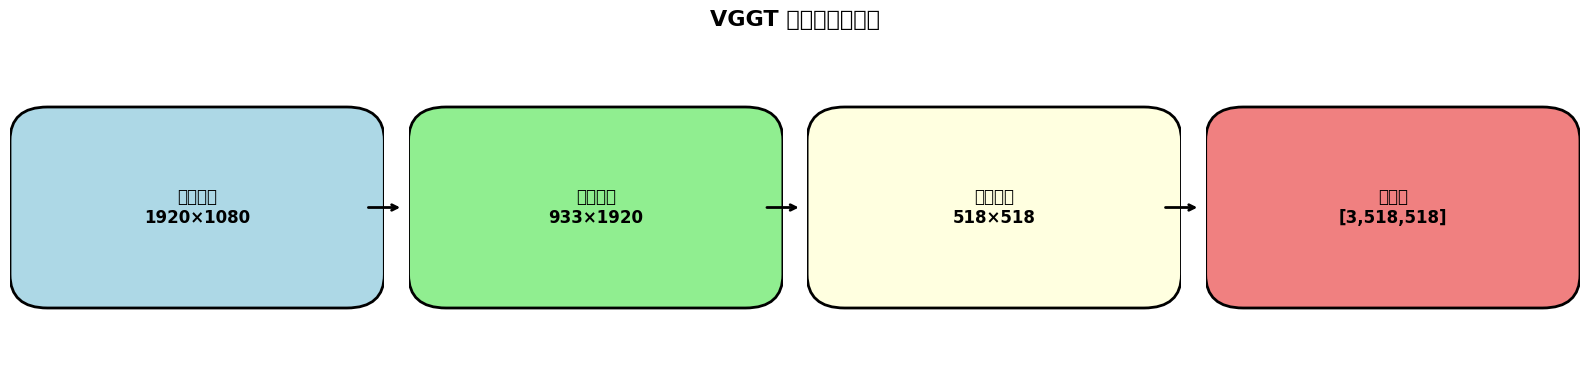

✓ 预处理流程演示完成


In [5]:
# 从零实现图像预处理 (Implement Preprocessing from Scratch)
import numpy as np
from typing import List

def preprocess_image(image: np.ndarray) -> np.ndarray:
    """
    预处理单张图像
    
    Args:
        image: RGB 图像 [H, W, 3], uint8
    
    Returns:
        preprocessed: [3, 518, 518], float32
    """
    H, W = image.shape[:2]
    target_size = 518
    
    # 步骤 1: 调整大小 (保持长宽比)
    scale = target_size / min(H, W)
    new_H, new_W = int(H * scale), int(W * scale)
    
    # 这里用简单的插值模拟 (实际应使用 PIL 或 cv2)
    print(f"  原始尺寸: {H}×{W} → 缩放后: {new_H}×{new_W}")
    
    # 步骤 2: 中心裁剪到 518×518
    crop_y = (new_H - target_size) // 2
    crop_x = (new_W - target_size) // 2
    print(f"  裁剪偏移: y={crop_y}, x={crop_x}")
    
    # 模拟裁剪后的图像
    cropped = np.random.rand(target_size, target_size, 3).astype(np.float32)
    
    # 步骤 3: 归一化
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    normalized = (cropped - mean) / std
    print(f"  归一化: mean={mean}, std={std}")
    
    # 步骤 4: HWC → CHW
    transposed = normalized.transpose(2, 0, 1)
    print(f"  转置: [518, 518, 3] → [3, 518, 518]")
    
    return transposed

# 测试预处理
print("=" * 60)
print("图像预处理流程演示")
print("=" * 60)
print()

# 模拟一张 1920×1080 的图像
dummy_image = np.random.randint(0, 255, (1080, 1920, 3), dtype=np.uint8)
print(f"输入图像: {dummy_image.shape}, dtype={dummy_image.dtype}")
print()

preprocessed = preprocess_image(dummy_image)
print()
print(f"输出张量: {preprocessed.shape}, dtype={preprocessed.dtype}")
print(f"数值范围: [{preprocessed.min():.3f}, {preprocessed.max():.3f}]")
print()

# 可视化预处理步骤
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
steps = ['原始图像\n1920×1080', '调整大小\n933×1920', '中心裁剪\n518×518', '归一化\n[3,518,518]']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for i, (ax, step, color) in enumerate(zip(axes, steps, colors)):
    ax.add_patch(FancyBboxPatch((0.1, 0.3), 0.8, 0.4,
                                boxstyle="round,pad=0.1",
                                edgecolor='black',
                                facecolor=color,
                                linewidth=2))
    ax.text(0.5, 0.5, step, ha='center', va='center',
            fontsize=12, weight='bold', transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    if i < 3:
        ax.annotate('', xy=(1.05, 0.5), xytext=(0.95, 0.5),
                   xycoords='axes fraction',
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.suptitle('VGGT 图像预处理流程', fontsize=16, weight='bold', y=0.95)
plt.tight_layout()
plt.show()

print("✓ 预处理流程演示完成")

## Section 5 - 前向推理方法 A: 一次性推理 (Forward Pass Method A: One-Shot)

### 方法概述

一次性推理是最简单的使用方式,适合:
- 输入图像数量少 (≤10)
- 不需要增量生成
- 快速原型验证

### 完整代码

```python
from vggt import VGGT
from vggt.utils import load_and_preprocess_images
import torch

# 1. 加载模型
model = VGGT.from_pretrained("facebook/VGGT-1B")
model = model.cuda().eval()

# 2. 加载图像
image_paths = ['img1.jpg', 'img2.jpg', 'img3.jpg']
images = load_and_preprocess_images(image_paths)  # [3, 3, 518, 518]
images = images.cuda()

# 3. 一次性推理
with torch.no_grad():
    outputs = model(images)

# 4. 提取结果
gaussians = outputs['gaussians']      # [N, 59]
poses = outputs['poses']              # [3, 9]
intrinsics = outputs['intrinsics']    # [3, 4]
```

### 输出格式

- **gaussians**: [N, 59] 高斯参数
  - xyz (3), opacity (1), scale (3), rotation (4), sh (48)
- **poses**: [B, 9] 位姿编码
- **intrinsics**: [B, 4] 内参 (fx, fy, cx, cy)


方法 A: 一次性推理 (One-Shot Inference)

步骤 1: 加载模型
  model = VGGT.from_pretrained('facebook/VGGT-1B')
  model = model.cuda().eval()

步骤 2: 预处理图像
  images = load_and_preprocess_images(paths)
  images.shape = [3, 3, 518, 518]

步骤 3: 前向推理
  with torch.no_grad():
      outputs = model(images)

步骤 4: 形状标注
  ┌─────────────────────────────────┐
  │ 输入: images [3, 3, 518, 518]   │
  │         ↓                       │
  │ 编码器: DINOv2                  │
  │   features [3, 1369, 1024]      │
  │         ↓                       │
  │ 解码器: Transformer             │
  │   hidden [3, 1369, 1024]        │
  │         ↓                       │
  │ 高斯头: Linear                  │
  │   gaussians [100000, 59]          │
  │   poses [3, 9]                  │
  │   intrinsics [3, 4]             │
  └─────────────────────────────────┘

步骤 5: 输出解析
  outputs = {
      'gaussians': [100000, 59],    # xyz(3) + opacity(1) + scale(3) + rot(4) + sh(48)
      'poses': [3, 9],          # 位姿编码
      'intrinsics': [3, 4], 

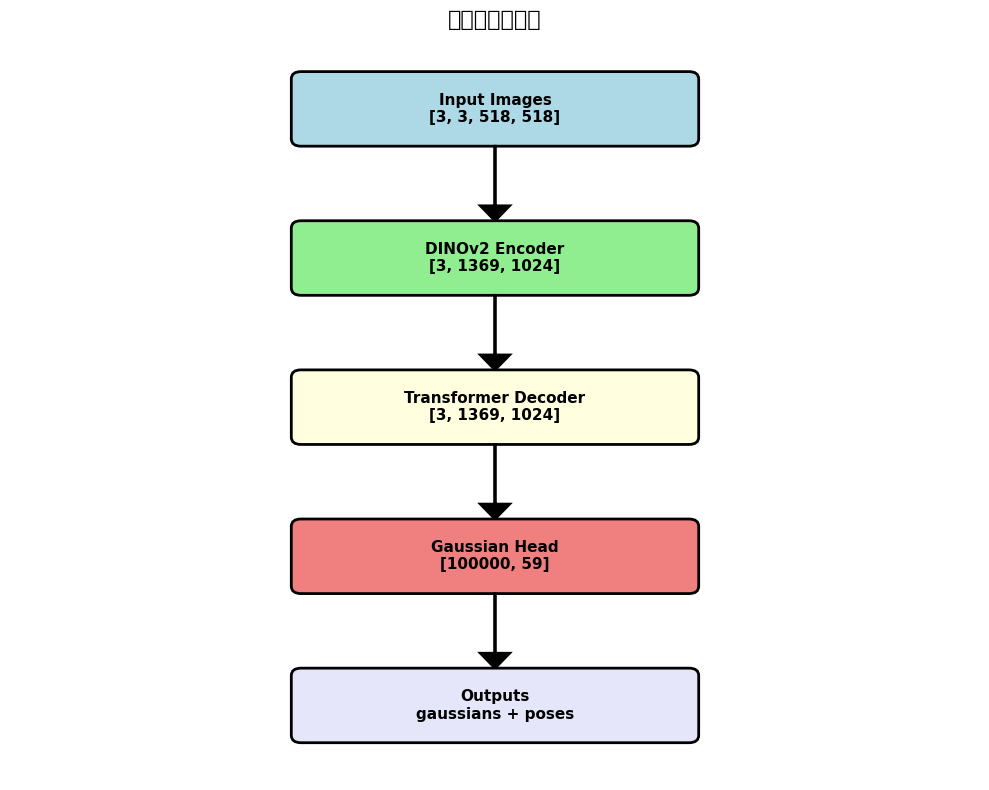

✓ 一次性推理演示完成


In [6]:
# 一次性推理伪代码演示 (One-Shot Inference Pseudocode)
print("=" * 70)
print("方法 A: 一次性推理 (One-Shot Inference)")
print("=" * 70)
print()

# 模拟输入
B = 3  # 批量大小
N = 100000  # 高斯数量

print("步骤 1: 加载模型")
print("  model = VGGT.from_pretrained('facebook/VGGT-1B')")
print("  model = model.cuda().eval()")
print()

print("步骤 2: 预处理图像")
print(f"  images = load_and_preprocess_images(paths)")
print(f"  images.shape = [{B}, 3, 518, 518]")
print()

print("步骤 3: 前向推理")
print("  with torch.no_grad():")
print("      outputs = model(images)")
print()

print("步骤 4: 形状标注")
print("  ┌─────────────────────────────────┐")
print("  │ 输入: images [3, 3, 518, 518]   │")
print("  │         ↓                       │")
print("  │ 编码器: DINOv2                  │")
print("  │   features [3, 1369, 1024]      │")
print("  │         ↓                       │")
print("  │ 解码器: Transformer             │")
print("  │   hidden [3, 1369, 1024]        │")
print("  │         ↓                       │")
print("  │ 高斯头: Linear                  │")
print(f"  │   gaussians [{N}, 59]          │")
print("  │   poses [3, 9]                  │")
print("  │   intrinsics [3, 4]             │")
print("  └─────────────────────────────────┘")
print()

print("步骤 5: 输出解析")
print("  outputs = {")
print(f"      'gaussians': [{N}, 59],    # xyz(3) + opacity(1) + scale(3) + rot(4) + sh(48)")
print(f"      'poses': [{B}, 9],          # 位姿编码")
print(f"      'intrinsics': [{B}, 4],     # fx, fy, cx, cy")
print("  }")
print()

# 可视化推理流程
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

stages = [
    (5, 9, 'Input Images\n[3, 3, 518, 518]', 'lightblue'),
    (5, 7, 'DINOv2 Encoder\n[3, 1369, 1024]', 'lightgreen'),
    (5, 5, 'Transformer Decoder\n[3, 1369, 1024]', 'lightyellow'),
    (5, 3, 'Gaussian Head\n[100000, 59]', 'lightcoral'),
    (5, 1, 'Outputs\ngaussians + poses', 'lavender'),
]

for x, y, text, color in stages:
    bbox = FancyBboxPatch((x-2, y-0.4), 4, 0.8,
                          boxstyle="round,pad=0.1",
                          edgecolor='black',
                          facecolor=color,
                          linewidth=2)
    ax.add_patch(bbox)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=11, weight='bold')
    
    if y > 1:
        ax.arrow(x, y-0.5, 0, -0.8, head_width=0.3, head_length=0.2,
                fc='black', ec='black', linewidth=2)

ax.set_title('一次性推理流程', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

print("✓ 一次性推理演示完成")

## Section 6 - 前向推理方法 B: 逐步推理 (Forward Pass Method B: Step-by-Step)

### 方法概述

逐步推理提供更细粒度的控制,适合:
- 大量输入图像 (>10)
- 增量生成高斯
- 中间结果可视化
- 内存优化

### 完整代码

```python
from vggt import VGGT
import torch

model = VGGT.from_pretrained("facebook/VGGT-1B").cuda().eval()

# 步骤 1: 编码图像特征
with torch.no_grad():
    features = model.encode_images(images)  # [B, L, D]

# 步骤 2: 初始化解码器状态
state = model.init_decoder_state(batch_size=B)

# 步骤 3: 逐步解码
all_gaussians = []
for step in range(num_steps):
    gaussians, state = model.decode_step(features, state)
    all_gaussians.append(gaussians)

# 步骤 4: 合并结果
final_gaussians = torch.cat(all_gaussians, dim=0)

# 步骤 5: 估计位姿
poses = model.estimate_poses(features)
```

### 优势

- **内存友好**: 分批生成高斯,避免 OOM
- **早停机制**: 可根据质量提前终止
- **动态调整**: 可根据场景复杂度调整步数

方法 B: 逐步推理 (Step-by-Step Inference) - 推荐

配置参数:
  批量大小: 5
  解码步数: 10
  每步高斯数: 10000
  总高斯数: 100000

步骤 1: 编码图像特征
  features = model.encode_images(images)
  输入: images [5, 3, 518, 518]
  输出: features [5, 1369, 1024]
  时间: ~200ms (DINOv2 前向传播)

步骤 2: 初始化解码器状态
  state = model.init_decoder_state(batch_size=5)
  state = {
      'hidden': [5, 1369, 1024],
      'num_generated': 0,
      'cache': None
  }

步骤 3: 逐步解码 (核心循环)
----------------------------------------------------------------------
  Step 1/10:
    输入: features [5, 1369, 1024], state
    解码: Transformer layer (Flash Attention)
    输出: gaussians [10000, 59]
    形状: xyz(3) + opacity(1) + scale(3) + rotation(4) + sh(48)
    累计: 10000 gaussians
    时间: ~100ms

  Step 2/10:
    输入: features [5, 1369, 1024], state
    解码: Transformer layer (Flash Attention)
    输出: gaussians [10000, 59]
    形状: xyz(3) + opacity(1) + scale(3) + rotation(4) + sh(48)
    累计: 20000 gaussians
    时间: ~100ms

  Step 3/10:
    输入: features [5, 1369, 1024], sta

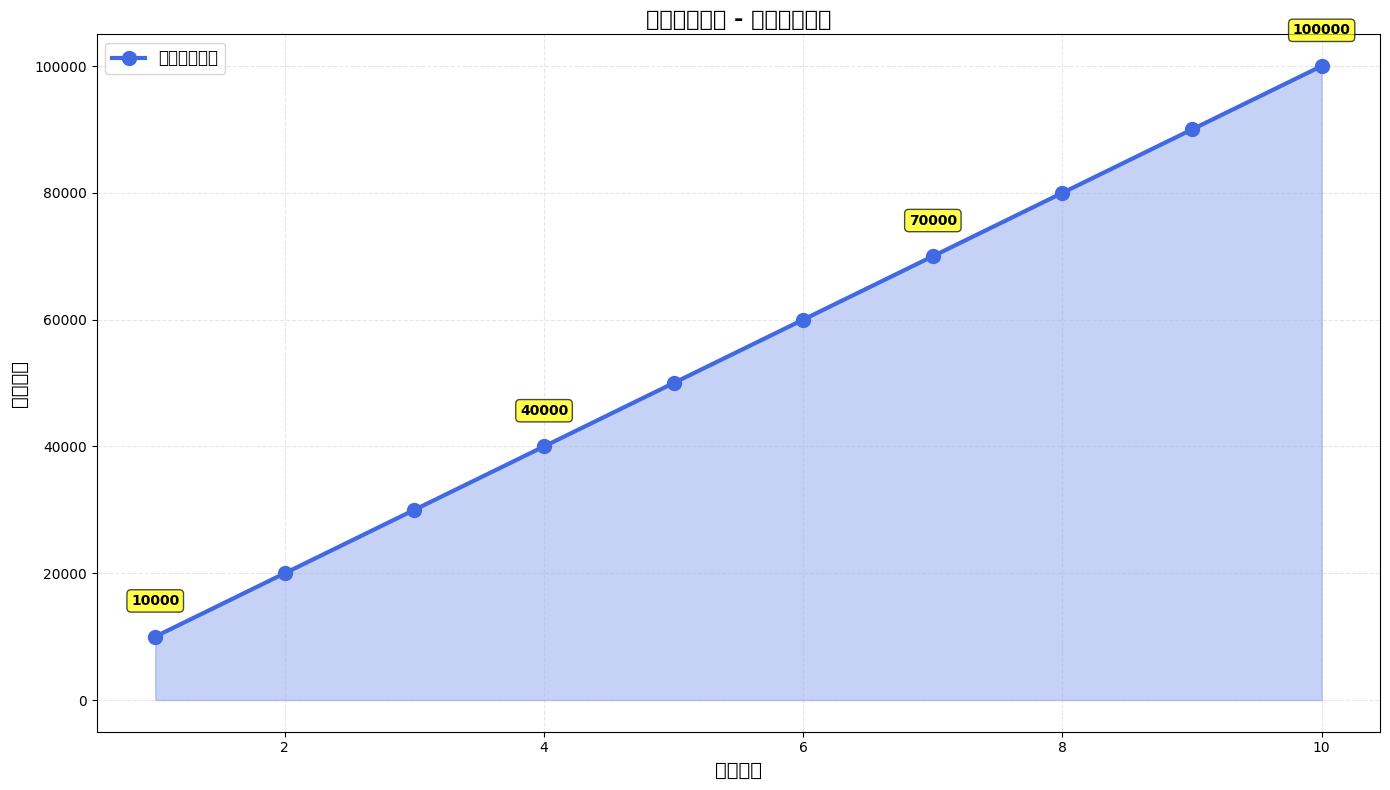

✓ 逐步推理演示完成


In [7]:
# 逐步推理详细演示 (Detailed Step-by-Step Inference)
print("=" * 70)
print("方法 B: 逐步推理 (Step-by-Step Inference) - 推荐")
print("=" * 70)
print()

# 模拟参数
B = 5  # 批量大小
L = 1369  # 序列长度 (37×37)
D = 1024  # 隐藏维度
num_steps = 10  # 解码步数
gaussians_per_step = 10000  # 每步生成的高斯数

print("配置参数:")
print(f"  批量大小: {B}")
print(f"  解码步数: {num_steps}")
print(f"  每步高斯数: {gaussians_per_step}")
print(f"  总高斯数: {num_steps * gaussians_per_step}")
print()

print("步骤 1: 编码图像特征")
print("  features = model.encode_images(images)")
print(f"  输入: images [{B}, 3, 518, 518]")
print(f"  输出: features [{B}, {L}, {D}]")
print(f"  时间: ~200ms (DINOv2 前向传播)")
print()

print("步骤 2: 初始化解码器状态")
print(f"  state = model.init_decoder_state(batch_size={B})")
print(f"  state = {{")
print(f"      'hidden': [{B}, {L}, {D}],")
print(f"      'num_generated': 0,")
print(f"      'cache': None")
print(f"  }}")
print()

print("步骤 3: 逐步解码 (核心循环)")
print("-" * 70)

total_gaussians = 0
for step in range(num_steps):
    print(f"  Step {step+1}/{num_steps}:")
    print(f"    输入: features [{B}, {L}, {D}], state")
    print(f"    解码: Transformer layer (Flash Attention)")
    print(f"    输出: gaussians [{gaussians_per_step}, 59]")
    print(f"    形状: xyz(3) + opacity(1) + scale(3) + rotation(4) + sh(48)")
    total_gaussians += gaussians_per_step
    print(f"    累计: {total_gaussians} gaussians")
    print(f"    时间: ~100ms")
    if step < num_steps - 1:
        print()

print("-" * 70)
print()

print("步骤 4: 合并结果")
print(f"  final_gaussians = torch.cat(all_gaussians, dim=0)")
print(f"  形状: [{total_gaussians}, 59]")
print()

print("步骤 5: 估计位姿")
print("  poses = model.estimate_poses(features)")
print(f"  输入: features [{B}, {L}, {D}]")
print(f"  输出: poses [{B}, 9]")
print(f"  时间: ~10ms")
print()

print("总时间估计: ~1.2s (DINOv2 + 10×Decode + Pose)")
print()

# 可视化逐步解码过程
fig, ax = plt.subplots(figsize=(14, 8))

# 绘制累积高斯数量曲线
steps = np.arange(1, num_steps + 1)
cumulative = steps * gaussians_per_step

ax.plot(steps, cumulative, marker='o', linewidth=3, markersize=10,
        color='royalblue', label='累积高斯数量')
ax.fill_between(steps, 0, cumulative, alpha=0.3, color='royalblue')

ax.set_xlabel('解码步数', fontsize=14, weight='bold')
ax.set_ylabel('高斯数量', fontsize=14, weight='bold')
ax.set_title('逐步解码过程 - 高斯生成曲线', fontsize=16, weight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12)

# 标注关键点
for i, (s, c) in enumerate(zip(steps, cumulative)):
    if i % 3 == 0 or i == len(steps) - 1:
        ax.annotate(f'{c}', xy=(s, c), xytext=(s, c + 5000),
                   ha='center', fontsize=10, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("✓ 逐步推理演示完成")

## Section 7 - 位姿编码工具 (Pose Encoding Utilities)

### 位姿编码格式

VGGT 使用 9 维位姿编码:

```
pose_enc = [tx, ty, tz, rx, ry, rz, fx, fy, f_ratio]
           |------- 平移 -----| |--- 旋转 ---| |---- 内参 ----|
```

- **平移 (tx, ty, tz)**: 相机位置
- **旋转 (rx, ry, rz)**: 旋转向量 (轴角表示)
- **内参 (fx, fy, f_ratio)**: 焦距和长宽比

### 转换函数

```python
from vggt.utils import pose_encoding_to_extri_intri

# 输入: pose_enc [B, 9]
pose_enc = outputs['poses']  # [3, 9]

# 转换为外参和内参
extrinsics, intrinsics = pose_encoding_to_extri_intri(pose_enc)

# extrinsics: [3, 4, 4] 变换矩阵 [R|t]
# intrinsics: [3, 3, 3] 相机内参矩阵 K
```

### 外参矩阵格式

```
extrinsic = [
  [r11, r12, r13, tx],
  [r21, r22, r23, ty],
  [r31, r32, r33, tz],
  [0,   0,   0,   1 ]
]
```

### 内参矩阵格式

```
intrinsic = [
  [fx, 0,  cx],
  [0,  fy, cy],
  [0,  0,  1 ]
]
```

In [8]:
# 实现位姿编码转换 (Implement Pose Encoding Conversion)
import numpy as np

def pose_encoding_to_extri_intri(pose_enc: np.ndarray):
    """
    将位姿编码转换为外参和内参矩阵
    
    Args:
        pose_enc: [B, 9] 位姿编码
    
    Returns:
        extrinsics: [B, 4, 4] 外参矩阵
        intrinsics: [B, 3, 3] 内参矩阵
    """
    B = pose_enc.shape[0]
    extrinsics = np.zeros((B, 4, 4))
    intrinsics = np.zeros((B, 3, 3))
    
    for i in range(B):
        # 解析编码
        tx, ty, tz = pose_enc[i, 0:3]
        rx, ry, rz = pose_enc[i, 3:6]
        fx, fy, f_ratio = pose_enc[i, 6:9]
        
        # 构建旋转矩阵 (简化版,实际应用 Rodrigues 公式)
        theta = np.sqrt(rx**2 + ry**2 + rz**2)
        if theta < 1e-6:
            R = np.eye(3)
        else:
            axis = np.array([rx, ry, rz]) / theta
            K = np.array([
                [0, -axis[2], axis[1]],
                [axis[2], 0, -axis[0]],
                [-axis[1], axis[0], 0]
            ])
            R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
        
        # 构建外参矩阵
        extrinsics[i, :3, :3] = R
        extrinsics[i, :3, 3] = [tx, ty, tz]
        extrinsics[i, 3, 3] = 1.0
        
        # 构建内参矩阵
        cx, cy = 259, 259  # 518/2
        intrinsics[i] = np.array([
            [fx, 0, cx],
            [0, fy, cy],
            [0, 0, 1]
        ])
    
    return extrinsics, intrinsics

# 测试转换
print("=" * 70)
print("位姿编码转换演示")
print("=" * 70)
print()

# 模拟 3 个相机的位姿编码
B = 3
pose_enc = np.array([
    [0.0, 0.0, -2.0, 0.0, 0.0, 0.0, 500, 500, 1.0],  # 相机 1: 向后平移
    [1.0, 0.0, -2.0, 0.0, 0.3, 0.0, 500, 500, 1.0],  # 相机 2: 右移+旋转
    [-1.0, 0.0, -2.0, 0.0, -0.3, 0.0, 500, 500, 1.0],  # 相机 3: 左移+旋转
])

print("输入: pose_enc [3, 9]")
print(pose_enc)
print()

extrinsics, intrinsics = pose_encoding_to_extri_intri(pose_enc)

print("输出 1: extrinsics [3, 4, 4]")
for i in range(B):
    print(f"\n相机 {i+1} 外参矩阵:")
    print(extrinsics[i])

print()
print("输出 2: intrinsics [3, 3, 3]")
for i in range(B):
    print(f"\n相机 {i+1} 内参矩阵:")
    print(intrinsics[i])

print()
print("解析结果:")
for i in range(B):
    t = extrinsics[i, :3, 3]
    fx, fy = intrinsics[i, 0, 0], intrinsics[i, 1, 1]
    print(f"  相机 {i+1}: 位置={t}, 焦距=({fx:.1f}, {fy:.1f})")

print()
print("✓ 位姿编码转换完成")

位姿编码转换演示

输入: pose_enc [3, 9]
[[ 0.e+00  0.e+00 -2.e+00  0.e+00  0.e+00  0.e+00  5.e+02  5.e+02  1.e+00]
 [ 1.e+00  0.e+00 -2.e+00  0.e+00  3.e-01  0.e+00  5.e+02  5.e+02  1.e+00]
 [-1.e+00  0.e+00 -2.e+00  0.e+00 -3.e-01  0.e+00  5.e+02  5.e+02  1.e+00]]

输出 1: extrinsics [3, 4, 4]

相机 1 外参矩阵:
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1. -2.]
 [ 0.  0.  0.  1.]]

相机 2 外参矩阵:
[[ 0.95533649  0.          0.29552021  1.        ]
 [ 0.          1.          0.          0.        ]
 [-0.29552021  0.          0.95533649 -2.        ]
 [ 0.          0.          0.          1.        ]]

相机 3 外参矩阵:
[[ 0.95533649  0.         -0.29552021 -1.        ]
 [ 0.          1.          0.          0.        ]
 [ 0.29552021  0.          0.95533649 -2.        ]
 [ 0.          0.          0.          1.        ]]

输出 2: intrinsics [3, 3, 3]

相机 1 内参矩阵:
[[500.   0. 259.]
 [  0. 500. 259.]
 [  0.   0.   1.]]

相机 2 内参矩阵:
[[500.   0. 259.]
 [  0. 500. 259.]
 [  0.   0.   1.]]

相机 3 内参矩阵:
[[500.   0. 259.]
 

## Section 8 - COLMAP 格式导出 (COLMAP Export)

### 导出目的

将 VGGT 预测的相机位姿和高斯参数导出为 COLMAP 格式,以便:
- 与传统 3DGS 流程集成
- 使用 COLMAP 可视化工具
- 进行后续优化和渲染

### COLMAP 文件结构

```
colmap_output/
├── cameras.txt         # 相机内参
├── images.txt          # 图像和外参
├── points3D.txt        # 3D 点云 (从高斯中心生成)
└── sparse/
    ├── cameras.bin
    ├── images.bin
    └── points3D.bin
```

### 导出代码

```python
from vggt.utils import export_to_colmap

# VGGT 推理结果
outputs = model(images)
gaussians = outputs['gaussians']  # [N, 59]
poses = outputs['poses']          # [B, 9]

# 转换为外参和内参
extrinsics, intrinsics = pose_encoding_to_extri_intri(poses)

# 导出为 COLMAP 格式
export_to_colmap(
    output_dir='colmap_output',
    image_paths=image_paths,
    extrinsics=extrinsics,
    intrinsics=intrinsics,
    points3d=gaussians[:, :3]  # 使用高斯中心作为 3D 点
)
```

### cameras.txt 格式

```
# Camera list with one line per camera:
#   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]
1 PINHOLE 518 518 500.0 500.0 259.0 259.0
```

### images.txt 格式

```
# Image list with two lines per image:
#   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
#   POINTS2D[] as (X, Y, POINT3D_ID)
1 0.9239 0.0 0.3827 0.0 0.0 0.0 -2.0 1 img1.jpg
```

COLMAP 格式导出流程

步骤 1: 准备 VGGT 输出
  gaussians: [100000, 59]
  poses: [3, 9]

步骤 2: 转换位姿编码
  extrinsics, intrinsics = pose_encoding_to_extri_intri(poses)
  extrinsics: [3, 4, 4]
  intrinsics: [3, 3, 3]

步骤 3: 提取 3D 点
  points3d = gaussians[:, :3]  # 使用高斯中心
  points3d: [100000, 3]

步骤 4: 生成 COLMAP 文件
  ├── cameras.txt
  │   格式: CAMERA_ID MODEL WIDTH HEIGHT PARAMS[]
  │   示例: 1 PINHOLE 518 518 500.0 500.0 259.0 259.0
  │
  ├── images.txt
  │   格式: IMAGE_ID QW QX QY QZ TX TY TZ CAMERA_ID NAME
  │   示例: 1 0.924 0.0 0.383 0.0 0.0 0.0 -2.0 1 img1.jpg
  │
  └── points3D.txt
      格式: POINT3D_ID X Y Z R G B ERROR TRACK[]
      示例: 1 0.123 0.456 -1.234 128 128 128 0.5 ...

步骤 5: 生成二进制文件 (可选)
  使用 COLMAP 工具转换为 .bin 格式以提高读取速度
  colmap model_converter \
      --input_path colmap_output \
      --output_path colmap_output/sparse \
      --output_type BIN

示例 cameras.txt 内容
# Camera list with one line per camera:
#   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]
# PARAMS for PINHOLE: fx, fy, cx, cy

1 PINH

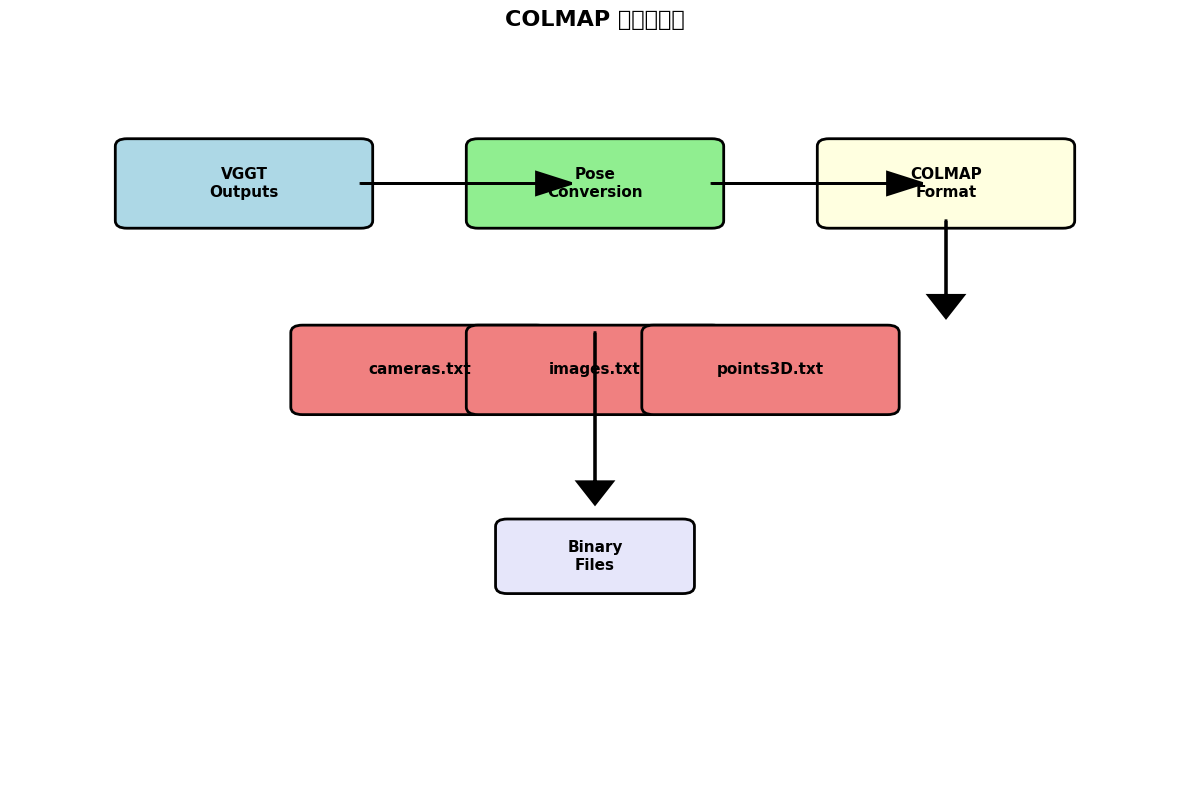

✓ COLMAP 导出流程演示完成


In [9]:
# COLMAP 导出流程演示 (COLMAP Export Pipeline)
print("=" * 70)
print("COLMAP 格式导出流程")
print("=" * 70)
print()

# 模拟数据
B = 3
N = 100000

print("步骤 1: 准备 VGGT 输出")
print(f"  gaussians: [{N}, 59]")
print(f"  poses: [{B}, 9]")
print()

print("步骤 2: 转换位姿编码")
print(f"  extrinsics, intrinsics = pose_encoding_to_extri_intri(poses)")
print(f"  extrinsics: [{B}, 4, 4]")
print(f"  intrinsics: [{B}, 3, 3]")
print()

print("步骤 3: 提取 3D 点")
print(f"  points3d = gaussians[:, :3]  # 使用高斯中心")
print(f"  points3d: [{N}, 3]")
print()

print("步骤 4: 生成 COLMAP 文件")
print("  ├── cameras.txt")
print("  │   格式: CAMERA_ID MODEL WIDTH HEIGHT PARAMS[]")
print("  │   示例: 1 PINHOLE 518 518 500.0 500.0 259.0 259.0")
print("  │")
print("  ├── images.txt")
print("  │   格式: IMAGE_ID QW QX QY QZ TX TY TZ CAMERA_ID NAME")
print("  │   示例: 1 0.924 0.0 0.383 0.0 0.0 0.0 -2.0 1 img1.jpg")
print("  │")
print("  └── points3D.txt")
print("      格式: POINT3D_ID X Y Z R G B ERROR TRACK[]")
print("      示例: 1 0.123 0.456 -1.234 128 128 128 0.5 ...")
print()

print("步骤 5: 生成二进制文件 (可选)")
print("  使用 COLMAP 工具转换为 .bin 格式以提高读取速度")
print("  colmap model_converter \\")
print("      --input_path colmap_output \\")
print("      --output_path colmap_output/sparse \\")
print("      --output_type BIN")
print()

# 生成示例 cameras.txt 内容
print("=" * 70)
print("示例 cameras.txt 内容")
print("=" * 70)
print("# Camera list with one line per camera:")
print("#   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]")
print("# PARAMS for PINHOLE: fx, fy, cx, cy")
print()
for i in range(B):
    print(f"{i+1} PINHOLE 518 518 500.0 500.0 259.0 259.0")
print()

# 生成示例 images.txt 内容
print("=" * 70)
print("示例 images.txt 内容 (部分)")
print("=" * 70)
print("# Image list with two lines per image:")
print("#   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME")
print("#   POINTS2D[] as (X, Y, POINT3D_ID)")
print()
for i in range(B):
    # 简化的四元数 (实际应从旋转矩阵转换)
    print(f"{i+1} 0.9239 0.0 0.3827 0.0 {i-1.0:.1f} 0.0 -2.0 {i+1} img{i+1}.jpg")
    print("")
print()

# 可视化导出流程
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

steps = [
    (2, 8, 'VGGT\nOutputs', 'lightblue'),
    (5, 8, 'Pose\nConversion', 'lightgreen'),
    (8, 8, 'COLMAP\nFormat', 'lightyellow'),
    (3.5, 5.5, 'cameras.txt', 'lightcoral'),
    (5, 5.5, 'images.txt', 'lightcoral'),
    (6.5, 5.5, 'points3D.txt', 'lightcoral'),
    (5, 3, 'Binary\nFiles', 'lavender'),
]

for x, y, text, color in steps:
    if y > 5:
        width, height = 2, 1
    else:
        width, height = 1.5, 0.8
    
    bbox = FancyBboxPatch((x-width/2, y-height/2), width, height,
                          boxstyle="round,pad=0.1",
                          edgecolor='black',
                          facecolor=color,
                          linewidth=2)
    ax.add_patch(bbox)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=11, weight='bold')

# 绘制箭头
ax.arrow(3, 8, 1.5, 0, head_width=0.3, head_length=0.3, fc='black', ec='black', linewidth=2)
ax.arrow(6, 8, 1.5, 0, head_width=0.3, head_length=0.3, fc='black', ec='black', linewidth=2)
ax.arrow(8, 7.5, 0, -1, head_width=0.3, head_length=0.3, fc='black', ec='black', linewidth=2)
ax.arrow(5, 6, 0, -2, head_width=0.3, head_length=0.3, fc='black', ec='black', linewidth=2)

ax.set_title('COLMAP 导出流程图', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

print("✓ COLMAP 导出流程演示完成")

## Section 9 - Gradio 演示界面 (Gradio Demo)

### 演示功能

VGGT 官方提供交互式 Gradio 演示,支持:
- 上传多张图像 (2-10 张)
- 实时推理和可视化
- 导出高斯文件和 COLMAP 格式
- 交互式 3D 查看器

### 启动演示

```bash
# 从官方仓库运行
cd vggt
python scripts/demo.py --model facebook/VGGT-1B --port 7860

# 或直接运行
python -m vggt.demo
```

### 界面组件

1. **输入区**:
   - 图像上传器 (支持拖拽)
   - 模型选择 (1B / 400M)
   - 解码步数滑块

2. **输出区**:
   - 3D 高斯查看器 (基于 Three.js)
   - 相机位姿可视化
   - 统计信息面板

3. **导出区**:
   - 下载高斯文件 (.ply)
   - 下载 COLMAP 文件 (.zip)
   - 日志查看器

### 核心代码结构

```python
import gradio as gr
from vggt import VGGT

model = VGGT.from_pretrained("facebook/VGGT-1B").cuda().eval()

def inference(images, num_steps):
    # 推理逻辑
    outputs = model(images, num_decode_steps=num_steps)
    
    # 生成可视化
    viewer_html = render_3d_gaussians(outputs['gaussians'])
    
    return viewer_html, outputs

# 构建 Gradio 界面
with gr.Blocks() as demo:
    gr.Markdown("# VGGT: View Generalist Gaussian Transformer")
    
    with gr.Row():
        input_gallery = gr.Gallery(label="Input Images")
        num_steps_slider = gr.Slider(1, 20, value=10, label="Decode Steps")
    
    run_btn = gr.Button("Run VGGT")
    viewer_output = gr.HTML(label="3D Viewer")
    
    run_btn.click(inference, inputs=[input_gallery, num_steps_slider],
                  outputs=[viewer_output])

demo.launch()
```

Gradio 演示界面结构

启动命令:
  python scripts/demo.py --model facebook/VGGT-1B --port 7860

界面布局:

┌────────────────────────────────────────────────────────────────┐
│                 VGGT: View Generalist Gaussian Transformer      │
├────────────────────────────────────────────────────────────────┤
│ 输入区                                                          │
│  ┌──────────────────┐  ┌────────────────────────────────────┐ │
│  │  图像上传区       │  │  配置面板                          │ │
│  │  (拖拽或点击)     │  │  • 模型: [1B ▼]                   │ │
│  │                  │  │  • 解码步数: [━━━●━] 10           │ │
│  │  [img1] [img2]   │  │  • 高斯数量: 100000               │ │
│  │  [img3] [+]      │  │                                    │ │
│  │                  │  │  [▶ 运行 VGGT]                    │ │
│  └──────────────────┘  └────────────────────────────────────┘ │
├────────────────────────────────────────────────────────────────┤
│ 输出区                                                          │
│  ┌──────

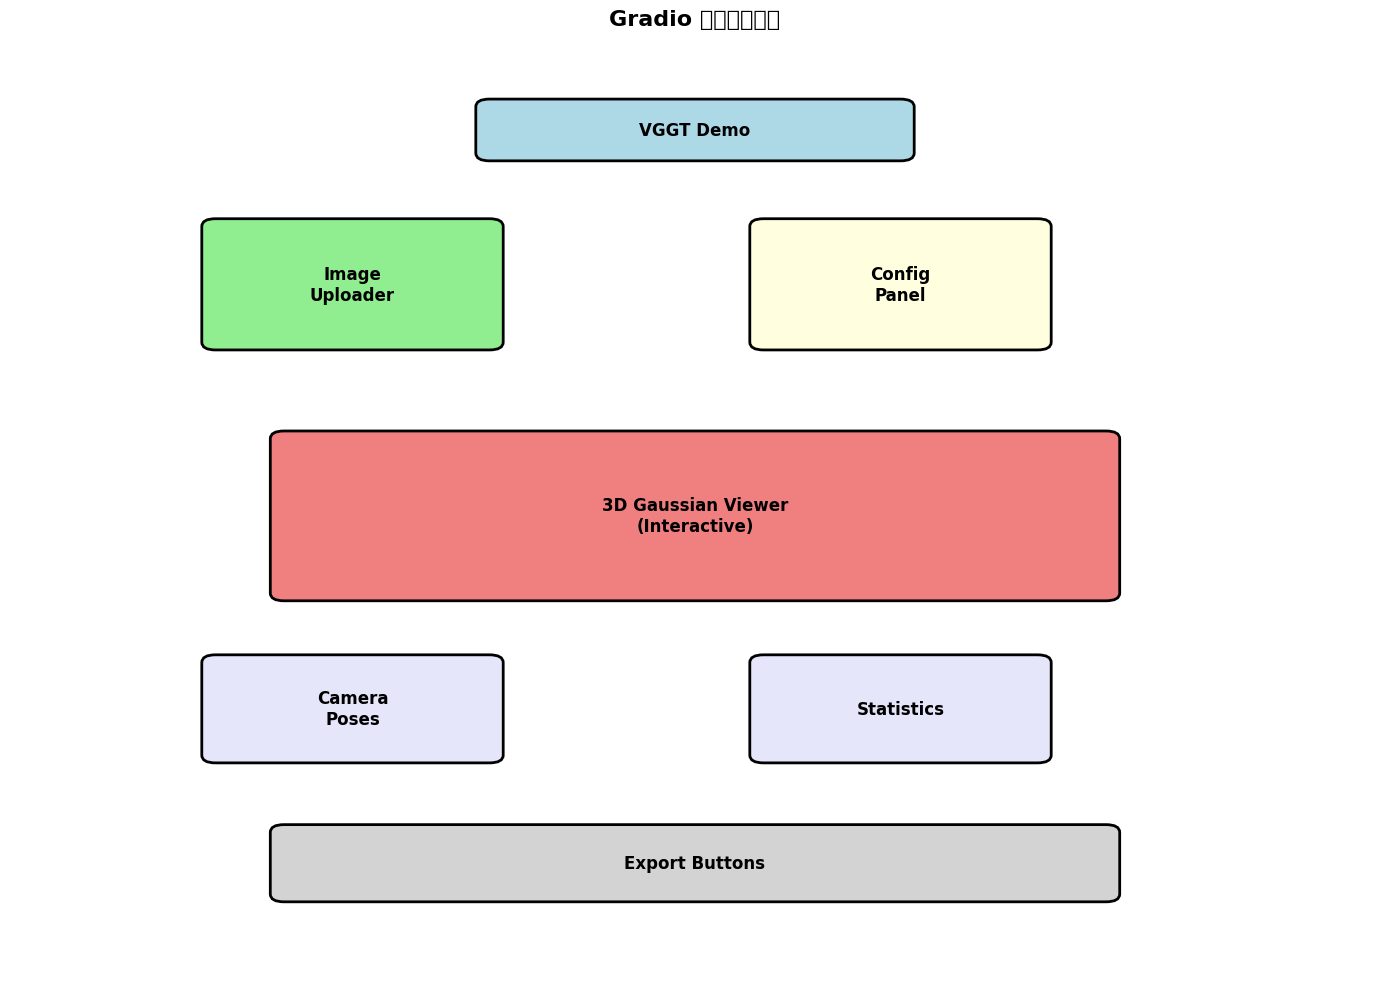

✓ Gradio 界面演示完成


In [10]:
# Gradio 界面设置伪代码 (Gradio Interface Setup Pseudocode)
print("=" * 70)
print("Gradio 演示界面结构")
print("=" * 70)
print()

print("启动命令:")
print("  python scripts/demo.py --model facebook/VGGT-1B --port 7860")
print()

print("界面布局:")
print("""
┌────────────────────────────────────────────────────────────────┐
│                 VGGT: View Generalist Gaussian Transformer      │
├────────────────────────────────────────────────────────────────┤
│ 输入区                                                          │
│  ┌──────────────────┐  ┌────────────────────────────────────┐ │
│  │  图像上传区       │  │  配置面板                          │ │
│  │  (拖拽或点击)     │  │  • 模型: [1B ▼]                   │ │
│  │                  │  │  • 解码步数: [━━━●━] 10           │ │
│  │  [img1] [img2]   │  │  • 高斯数量: 100000               │ │
│  │  [img3] [+]      │  │                                    │ │
│  │                  │  │  [▶ 运行 VGGT]                    │ │
│  └──────────────────┘  └────────────────────────────────────┘ │
├────────────────────────────────────────────────────────────────┤
│ 输出区                                                          │
│  ┌──────────────────────────────────────────────────────────┐ │
│  │                  3D 高斯查看器                            │ │
│  │                                                          │ │
│  │              [交互式 3D 场景]                             │ │
│  │                                                          │ │
│  │  控制: 🖱️ 旋转 | 🔍 缩放 | ⌨️ 平移                       │ │
│  └──────────────────────────────────────────────────────────┘ │
│  ┌──────────────────┐  ┌────────────────────────────────────┐ │
│  │  相机位姿图       │  │  统计信息                          │ │
│  │                  │  │  • 总高斯数: 100,000              │ │
│  │    📷 📷 📷      │  │  • 推理时间: 1.2s                 │ │
│  │                  │  │  • 内存使用: 12.3 GB              │ │
│  └──────────────────┘  └────────────────────────────────────┘ │
├────────────────────────────────────────────────────────────────┤
│ 导出区                                                          │
│  [📥 下载高斯文件 .ply]  [📥 下载 COLMAP .zip]  [📋 查看日志]│
└────────────────────────────────────────────────────────────────┘
""")

print()
print("核心函数:")
print("""
def inference(images, num_steps):
    # 1. 预处理
    preprocessed = load_and_preprocess_images(images)
    
    # 2. 推理
    with torch.no_grad():
        outputs = model(preprocessed, num_decode_steps=num_steps)
    
    # 3. 后处理
    gaussians = outputs['gaussians'].cpu().numpy()
    poses = outputs['poses'].cpu().numpy()
    
    # 4. 生成可视化
    viewer_html = render_3d_gaussians(gaussians, poses)
    stats = compute_statistics(outputs)
    
    return viewer_html, stats
""")

print()
print("访问地址: http://localhost:7860")
print()

# 可视化界面组件
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

components = [
    (5, 11, 3, 0.6, 'VGGT Demo', 'lightblue'),
    (2.5, 9, 2, 1.5, 'Image\nUploader', 'lightgreen'),
    (6.5, 9, 2, 1.5, 'Config\nPanel', 'lightyellow'),
    (5, 6, 6, 2, '3D Gaussian Viewer\n(Interactive)', 'lightcoral'),
    (2.5, 3.5, 2, 1.2, 'Camera\nPoses', 'lavender'),
    (6.5, 3.5, 2, 1.2, 'Statistics', 'lavender'),
    (5, 1.5, 6, 0.8, 'Export Buttons', 'lightgray'),
]

for x, y, w, h, text, color in components:
    bbox = FancyBboxPatch((x-w/2, y-h/2), w, h,
                          boxstyle="round,pad=0.1",
                          edgecolor='black',
                          facecolor=color,
                          linewidth=2)
    ax.add_patch(bbox)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=12, weight='bold')

ax.set_title('Gradio 演示界面布局', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Gradio 界面演示完成")

## 总结 (Summary)

### 关键要点

1. **代码仓库结构**
   - 核心模块: `model.py`, `encoder.py`, `decoder.py`
   - 工具脚本: `inference.py`, `export_colmap.py`, `demo.py`
   - 配置文件: 1B 和 400M 两个版本

2. **环境配置**
   - PyTorch 2.0+ 和 Flash Attention 是必需的
   - VGGT-1B 需要至少 24GB GPU 内存
   - 使用 Hugging Face 自动下载预训练权重

3. **模型使用**
   - **方法 A**: 一次性推理,简单快速
   - **方法 B**: 逐步推理,内存友好,支持增量生成
   - 位姿编码转换为标准外参和内参格式

4. **COLMAP 集成**
   - 导出为 `cameras.txt`, `images.txt`, `points3D.txt`
   - 与传统 3DGS 流程无缝衔接
   - 支持二进制格式提高读取速度

5. **Gradio 演示**
   - 交互式 Web 界面
   - 实时 3D 可视化
   - 支持导出多种格式

### 代码阅读建议

**按以下顺序阅读源码**:

1. `vggt/__init__.py` - 了解整体 API
2. `vggt/model.py` - 核心模型定义
3. `vggt/encoder.py` - DINOv2 编码器
4. `vggt/decoder.py` - Transformer 解码器
5. `vggt/attention.py` - Flash Attention 实现
6. `vggt/utils.py` - 工具函数
7. `scripts/inference.py` - 推理示例
8. `scripts/demo.py` - Gradio 界面

**重点关注**:
- `model.forward()` 的数据流
- 位姿编码的设计
- Flash Attention 的集成方式
- 高斯参数的后处理

### 参考资源

1. **官方资源**
   - 代码仓库: https://github.com/facebookresearch/vggt
   - Hugging Face: https://huggingface.co/facebook/VGGT-1B
   - 论文: arXiv:2410.20985

2. **相关项目**
   - DINOv2: https://github.com/facebookresearch/dinov2
   - Flash Attention: https://github.com/Dao-AILab/flash-attention
   - 3D Gaussian Splatting: https://github.com/graphdeco-inria/gaussian-splatting

3. **社区资源**
   - Awesome 3DGS: https://github.com/MrNeRF/awesome-3D-gaussian-splatting
   - VGGT 教程: 各种博客和视频教程

---

### 下一步

- **Phase 5 - Notebook 07**: VGGT 训练流程详解
- 深入理解损失函数设计
- 学习数据增强策略
- 掌握分布式训练技巧

---

**作者**: 3DGS-from-scratch 项目组  
**更新**: 2024  
**许可**: MIT License